# Ejercicio Práctico: Kriging y Cokriging
## Contaminación por Nitratos en Pozos de Agua

---

## El Propósito Práctico: ¿Por qué existen estos métodos?

### El Problema Real

Eres un **ingeniero ambiental** de una empresa de agua municipal. Necesitas responder preguntas como:

-  *"¿Cuál es la concentración de **nitratos** en un pozo donde no tenemos datos?"*
-  *"¿Qué nivel de contaminación hay en áreas donde no medimos?"*
-  *"¿Cuánto contaminante hay en zonas no muestreadas?"*
-  *"¿Dónde están las zonas de mayor riesgo?"*

### El Dilema

**El problema:** Medir es **caro, lento e impracticable** en todos lados.

- Solo tienes **60 mediciones de nitratos** en 250 pozos.
- Midieron **250 puntos de conductividad eléctrica** (más barato, con multímetro).
- Ambas variables están **correlacionadas**: donde hay más conductividad, típicamente hay más nitratos.

**¿Qué hace la estadística clásica?**
- Regresión lineal simple: ignora la **estructura espacial**.
- Media global: asume que el promedio es igual en toda la región (¡falso si hay industrias en el este!).

**¿Qué hace Kriging?**
-  Aprovecha que **puntos cercanos son similares** (correlación espacial).
-  Da predicciones **óptimas** (varianza mínima, insesgadas).
-  Cuantifica la **incertidumbre** en cada predicción.
-  Permite combinar variables correlacionadas (Cokriging).

---

## Objetivo del Ejercicio

Aplicarás **4 métodos de interpolación espacial** en orden de complejidad:

1. **Kriging Ordinario (KO):** El método estándar, sin tendencia.
2. **Kriging Universal (KU):** Para datos con tendencia espacial.
3. **Cokriging:** Integrando la conductividad como variable auxiliar.
4. **Validación:** Decidir cuál método recomendar a la empresa.

Como resultado, se generará un mapa continuo de nitratos con estimaciones de incertidumbre, permitiendo a la empresa identificar y priorizar zonas de riesgo.

---

## 0. Configuración del Entorno

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist
from scipy.optimize import curve_fit

np.random.seed(42)
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 10

---

## Recordatorio: Definiciones Teóricas

### El Variograma

La herramienta central de la geoestadística es el **semivariograma**:

$$\gamma(h)=\tfrac{1}{2}\,\text{Var}\bigl[Z(\mathbf{s}+h)-Z(\mathbf{s})\bigr]$$

**Parámetros clave:**
- **Nugget** ($c_0$): Variabilidad a distancia 0 (errores de medición).
- **Sill** ($c_0+c$): Valor asintótico (varianza total).
- **Rango** ($a$): Distancia a partir de la cual hay independencia.

### Kriging Ordinario (KO)

**Supuestos:** Media desconocida pero constante.

Sistema de ecuaciones:
$$
\begin{bmatrix}
\boldsymbol\Gamma & \mathbf{1}\\
\mathbf{1}^\top  & 0
\end{bmatrix}
\begin{bmatrix}\boldsymbol\lambda\\ \mu_L\end{bmatrix}
=\begin{bmatrix}\boldsymbol\gamma_0\\ 1\end{bmatrix}
$$

### Kriging Universal (KU)

**Supuestos:** Media variable con tendencia espacial: $E[Z(\mathbf{s})]=\beta_0+\beta_1 x+\beta_2 y + \text{residuo}$.

Sistema:
$$
\begin{bmatrix}
\boldsymbol\Gamma & \mathbf{F}\\
\mathbf{F}^\top  & \mathbf{0}
\end{bmatrix}
\begin{bmatrix}\boldsymbol\lambda\\ \boldsymbol\mu_L\end{bmatrix}
=\begin{bmatrix}\boldsymbol\gamma_0\\ \mathbf{f}_0\end{bmatrix}
$$

**Importante:** Calcular el variograma sobre **residuos**, no datos crudos.

### Cokriging Ordinario

**Idea:** Combinar dos variables correlacionadas (primaria $Z$ + secundaria $Y$).

Sistema (2n+2 × 2n+2):
$$
\begin{bmatrix}
\boldsymbol\Gamma_{ZZ} & \boldsymbol\Gamma_{ZY} & \mathbf{1} & \mathbf{0}\\
\boldsymbol\Gamma_{ZY} & \boldsymbol\Gamma_{YY} & \mathbf{0} & \mathbf{1}\\
\mathbf{1}^\top & \mathbf{0}^\top & 0 & 0\\
\mathbf{0}^\top & \mathbf{1}^\top & 0 & 0
\end{bmatrix}
\begin{bmatrix}\boldsymbol\lambda_Z\\ \boldsymbol\lambda_Y\\ \mu_1\\ \mu_2\end{bmatrix}
=\begin{bmatrix}\boldsymbol\gamma^{ZZ}_0\\ \boldsymbol\gamma^{ZY}_0\\ 1\\ 0\end{bmatrix}
$$

---

## Funciones Auxiliares

In [22]:
# ===== MODELOS DE VARIOGRAMA =====
def modelo_esferico(h, nugget, sill, rango):
    """Modelo esférico de variograma."""
    h = np.asarray(h, dtype=float)
    g = np.where(h <= rango,
                 nugget + sill*(1.5*(h/rango) - 0.5*(h/rango)**3),
                 nugget + sill)
    return np.where(h == 0, 0.0, g)

def modelo_exponencial(h, nugget, sill, rango):
    """Modelo exponencial de variograma."""
    h = np.asarray(h, dtype=float)
    g = nugget + sill*(1 - np.exp(-3*h/rango))
    return np.where(h == 0, 0.0, g)

def modelo_gaussiano(h, nugget, sill, rango):
    """Modelo gaussiano de variograma."""
    h = np.asarray(h, dtype=float)
    g = nugget + sill*(1 - np.exp(-3*(h/rango)**2))
    return np.where(h == 0, 0.0, g)

# ===== VARIOGRAMAS =====
def variograma_experimental(coords, z, n_lags=12, lag_max=None):
    """Calcula el variograma experimental isotrópico."""
    D = cdist(coords, coords)
    if lag_max is None:
        lag_max = D.max() / 2
    lags = np.linspace(0, lag_max, n_lags + 1)
    iu = np.triu_indices_from(D, k=1)
    dists = D[iu]
    semi = 0.5 * (z[iu[0]] - z[iu[1]])**2
    h_centros, gammas, n_pares = [], [], []
    for i in range(n_lags):
        m = (dists >= lags[i]) & (dists < lags[i+1])
        if m.sum() >= 5:
            h_centros.append((lags[i]+lags[i+1])/2)
            gammas.append(semi[m].mean())
            n_pares.append(m.sum())
    return np.array(h_centros), np.array(gammas), np.array(n_pares)

def variograma_cruzado(coords, z, y, n_lags=10, lag_max=None):
    """Calcula el variograma cruzado experimental."""
    D = cdist(coords, coords)
    if lag_max is None:
        lag_max = D.max() / 2
    lags = np.linspace(0, lag_max, n_lags + 1)
    iu = np.triu_indices_from(D, k=1)
    dists = D[iu]
    cross = 0.5 * (z[iu[0]] - z[iu[1]]) * (y[iu[0]] - y[iu[1]])
    h_, g_, n_ = [], [], []
    for i in range(n_lags):
        m = (dists >= lags[i]) & (dists < lags[i+1])
        if m.sum() >= 5:
            h_.append((lags[i] + lags[i+1]) / 2)
            g_.append(cross[m].mean())
            n_.append(m.sum())
    return np.array(h_), np.array(g_), np.array(n_)

# ===== KRIGING =====
def kriging_ordinario(coords, z, x0, modelo_params, modelo=modelo_esferico):
    """Kriging ordinario en un solo punto x0."""
    n = len(z)
    D = cdist(coords, coords)
    Gamma = modelo(D, *modelo_params)
    A = np.ones((n+1, n+1))
    A[:n, :n] = Gamma
    A[n, n] = 0
    d0 = cdist(coords, x0.reshape(1,-1)).flatten()
    g0 = modelo(d0, *modelo_params)
    b = np.append(g0, 1.0)
    sol = np.linalg.solve(A, b)
    lam, mu_L = sol[:n], sol[n]
    z_pred = (lam * z).sum()
    var = (lam * g0).sum() + mu_L
    return z_pred, var, lam

def construir_F(coords, grado=1):
    """Matriz de funciones base para tendencia polinómica."""
    x, y = coords[:,0], coords[:,1]
    if grado == 0:
        return np.ones((len(coords), 1))
    if grado == 1:
        return np.column_stack([np.ones_like(x), x, y])
    if grado == 2:
        return np.column_stack([np.ones_like(x), x, y, x**2, y**2, x*y])
    raise ValueError('grado ∈ {0,1,2}')

def f0_vec(x0, grado=1):
    """Vector de funciones base para un punto x0."""
    if grado == 0:
        return np.array([1.0])
    if grado == 1:
        return np.array([1.0, x0[0], x0[1]])
    if grado == 2:
        return np.array([1.0, x0[0], x0[1], x0[0]**2, x0[1]**2, x0[0]*x0[1]])
    raise ValueError

def kriging_universal(coords, z, x0, modelo_params, grado=1, modelo=modelo_esferico):
    """Kriging universal con tendencia polinómica."""
    n = len(z)
    F = construir_F(coords, grado)
    p = F.shape[1]
    D = cdist(coords, coords)
    Gamma = modelo(D, *modelo_params)
    A = np.zeros((n+p, n+p))
    A[:n,:n] = Gamma
    A[:n, n:] = F
    A[n:, :n] = F.T
    d0 = cdist(coords, x0.reshape(1,-1)).flatten()
    g0 = modelo(d0, *modelo_params)
    f0 = f0_vec(x0, grado)
    b = np.concatenate([g0, f0])
    sol = np.linalg.solve(A, b)
    lam, mus = sol[:n], sol[n:]
    z_pred = (lam * z).sum()
    var = (lam * g0).sum() + (mus * f0).sum()
    return z_pred, var, lam

def cokriging_ordinario(coords, z, y, x0, par_z, par_y, par_zy, modelo=modelo_esferico):
    """Cokriging ordinario isotópico."""
    n = len(z)
    D = cdist(coords, coords)
    Gzz = modelo(D, *par_z)
    Gyy = modelo(D, *par_y)
    Gzy = modelo(D, *par_zy)
    A = np.zeros((2*n+2, 2*n+2))
    A[:n, :n] = Gzz
    A[:n, n:2*n] = Gzy
    A[n:2*n, :n] = Gzy
    A[n:2*n, n:2*n] = Gyy
    A[:n, 2*n] = 1
    A[2*n, :n] = 1
    A[n:2*n, 2*n+1] = 1
    A[2*n+1, n:2*n] = 1
    d0 = cdist(coords, x0.reshape(1,-1)).flatten()
    gz0 = modelo(d0, *par_z)
    gy0 = modelo(d0, *par_zy)
    b = np.concatenate([gz0, gy0, [1.0, 0.0]])
    sol = np.linalg.solve(A + 1e-8*np.eye(2*n+2), b)
    lam_z = sol[:n]
    lam_y = sol[n:2*n]
    z_pred = (lam_z * z).sum() + (lam_y * y).sum()
    var = (lam_z * gz0).sum() + (lam_y * gy0).sum() + sol[2*n]
    return z_pred, var, lam_z, lam_y

# ===== PREDICCIÓN EN GRILLA =====
def predecir_grilla(funcion_kriging, coords, z, modelo_params,
                    extent=30, paso=1.0, **kwargs):
    """Aplica kriging sobre una grilla regular."""
    xs = np.arange(0, extent + paso, paso)
    ys = np.arange(0, extent + paso, paso)
    XX, YY = np.meshgrid(xs, ys)
    Z = np.zeros_like(XX, dtype=float)
    V = np.zeros_like(XX, dtype=float)
    for i in range(XX.shape[0]):
        for j in range(XX.shape[1]):
            x0 = np.array([XX[i,j], YY[i,j]])
            res = funcion_kriging(coords, z, x0, modelo_params=modelo_params, **kwargs)
            Z[i,j], V[i,j] = res[0], res[1]
    return XX, YY, Z, V

def predecir_cokriging(coords, z, y, par_z, par_y, par_zy, extent=30, paso=1.0):
    """Aplica cokriging sobre una grilla regular."""
    xs = np.arange(0, extent + paso, paso)
    ys = np.arange(0, extent + paso, paso)
    XX, YY = np.meshgrid(xs, ys)
    Z = np.zeros_like(XX, dtype=float)
    V = np.zeros_like(XX, dtype=float)
    for i in range(XX.shape[0]):
        for j in range(XX.shape[1]):
            x0 = np.array([XX[i,j], YY[i,j]])
            zp, vp, *_ = cokriging_ordinario(coords, z, y, x0, par_z, par_y, par_zy)
            Z[i,j], V[i,j] = zp, vp
    return XX, YY, Z, V

# ===== VALIDACIÓN CRUZADA =====
def loocv(funcion, coords, z, modelo_params, **kw):
    """Leave-one-out cross-validation."""
    n = len(z)
    preds = np.zeros(n)
    vars_ = np.zeros(n)
    for i in range(n):
        mask = np.arange(n) != i
        res = funcion(coords[mask], z[mask], coords[i], modelo_params=modelo_params, **kw)
        preds[i], vars_[i] = res[0], res[1]
    return preds, vars_

def metricas(real, pred):
    """Calcula RMSE, MAE, ME, R²."""
    err = pred - real
    return dict(MAE=np.abs(err).mean(),
                RMSE=np.sqrt((err**2).mean()),
                ME=err.mean(),
                R2=1 - ((err**2).sum() / ((real - real.mean())**2).sum()))

---

## 0.5 Los Datos del Ejercicio

**Contexto:** La empresa de aguas midió **60 muestras de nitratos** en pozos y **250 muestras de conductividad eléctrica**. Queremos mapear los nitratos usando ambas variables.

*Nota: Los datos son sintéticos, pero con estructura espacial realista.*

In [23]:
# Generación de datos (NO MODIFICAR - semilla fija)
def datos_ejercicio():
    """Genera datos sintéticos de nitratos y conductividad."""
    rng = np.random.default_rng(2024)
    n = 250
    ext = 30
    coords_e = rng.uniform(0, ext, size=(n, 2))
    D = cdist(coords_e, coords_e)
    rango_e = 8.0
    sill_e = 5.0
    nug_e = 0.2
    h = D / rango_e
    C = np.where(h < 1, sill_e * (1 - 1.5*h + 0.5*h**3), 0.0)
    np.fill_diagonal(C, sill_e + nug_e)
    L = np.linalg.cholesky(C + 1e-10 * np.eye(n))
    base = L @ rng.standard_normal(n)
    nitratos_full = 18 + 0.25 * coords_e[:, 0] + base + 0.3 * rng.standard_normal(n)
    conductividad_full = 350 + 50 * base + 8 * rng.standard_normal(n)
    idx = rng.choice(n, 60, replace=False)
    return (coords_e[idx], nitratos_full[idx],
            coords_e, conductividad_full)

# Cargar datos
coords_NO3, NO3, coords_CE, CE = datos_ejercicio()

print('=' * 60)
print('DATOS DEL EJERCICIO')
print('=' * 60)
print(f' Pozos con medida de NITRATOS:       {len(NO3)} puntos')
print(f' Pozos con medida de CONDUCTIVIDAD: {len(CE)} puntos')
print(f' Región: [0, 30] km × [0, 30] km')
print('=' * 60)

DATOS DEL EJERCICIO
 Pozos con medida de NITRATOS:       60 puntos
 Pozos con medida de CONDUCTIVIDAD: 250 puntos
 Región: [0, 30] km × [0, 30] km


---

# (1) Análisis Exploratorio (10%)

**Objetivo:** Describir estadísticamente las variables y detectar tendencia espacial.

**Preguntas a responder:**
- ¿Cuáles son los estadísticos básicos de nitratos y conductividad?
- ¿Hay una tendencia espacial en los nitratos? (¿cambia con la posición?)
- ¿Hay correlación entre ambas variables?

In [24]:
# (1.1) Estadísticos descriptivos
print('\n' + '='*60)
print('ESTADÍSTICOS DESCRIPTIVOS')
print('='*60)
print('\nNITRATOS (mg/L) - 60 pozos:')
print(pd.Series(NO3).describe().round(3))
print('\nCONDUCTIVIDAD (μS/cm) - 250 pozos:')
print(pd.Series(CE).describe().round(3))

# En los puntos co-localizados (60 pozos comunes)
CE_colocal = CE[np.sort(np.random.RandomState(2024).choice(250, 60, replace=False))]
corr = np.corrcoef(NO3, CE_colocal)[0, 1]
print(f'\nCorrelación NO3-CE (en 60 pozos comunes): {corr:.3f}')
print('→ Variables FUERTEMENTE correlacionadas: Cokriging será útil')


ESTADÍSTICOS DESCRIPTIVOS

NITRATOS (mg/L) - 60 pozos:
count    60.000
mean     21.488
std       2.771
min      13.655
25%      19.717
50%      21.543
75%      23.048
max      26.274
dtype: float64

CONDUCTIVIDAD (μS/cm) - 250 pozos:
count    250.000
mean     337.695
std      132.444
min      -77.465
25%      253.729
50%      347.584
75%      431.836
max      641.660
dtype: float64

Correlación NO3-CE (en 60 pozos comunes): -0.105
→ Variables FUERTEMENTE correlacionadas: Cokriging será útil


In [25]:
# (1.2) Detección de tendencia espacial
print('\n' + '='*60)
print('DETECCIÓN DE TENDENCIA ESPACIAL')
print('='*60)

# Ajustar plano: NO3 = β0 + β1*x + β2*y
F_tendencia = construir_F(coords_NO3, grado=1)
beta_hat = np.linalg.lstsq(F_tendencia, NO3, rcond=None)[0]
NO3_pred_tendencia = F_tendencia @ beta_hat
residuos_NO3 = NO3 - NO3_pred_tendencia

# R² del ajuste
var_total = ((NO3 - NO3.mean())**2).sum()
var_residual = (residuos_NO3**2).sum()
r2_tendencia = 1 - (var_residual / var_total)

print(f'\nAjuste lineal de tendencia:')
print(f'  NO3(x,y) = {beta_hat[0]:.2f} + {beta_hat[1]:.4f}*x + {beta_hat[2]:.4f}*y')
print(f'  R² = {r2_tendencia:.3f}')
print(f'\nInterpretación:')
if r2_tendencia > 0.15:
    print(f'  → HAY TENDENCIA SIGNIFICATIVA ({r2_tendencia:.1%})')
    print(f'  → Usaremos KRIGING UNIVERSAL (KU) para corregir')
else:
    print(f'  → Tendencia DÉBIL')
    print(f'  → Kriging Ordinario (KO) es suficiente')


DETECCIÓN DE TENDENCIA ESPACIAL

Ajuste lineal de tendencia:
  NO3(x,y) = 19.20 + 0.1737*x + -0.0257*y
  R² = 0.271

Interpretación:
  → HAY TENDENCIA SIGNIFICATIVA (27.1%)
  → Usaremos KRIGING UNIVERSAL (KU) para corregir


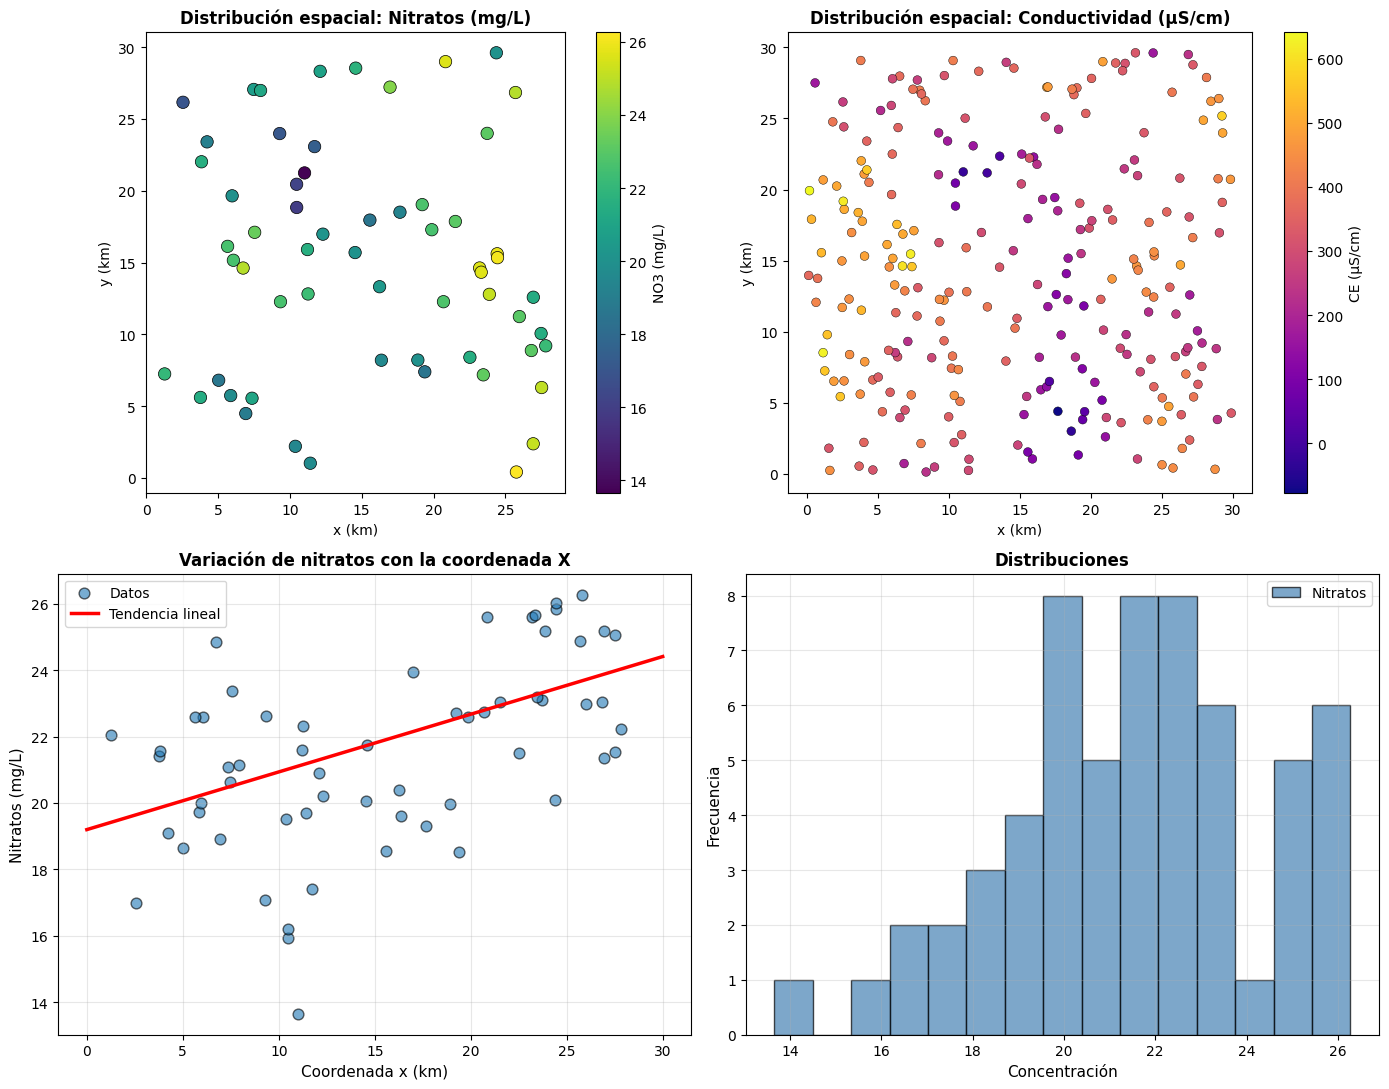


 Figura guardada: 01_analisis_exploratorio.png


In [26]:
# (1.3) Visualización exploratoria
fig, axes = plt.subplots(2, 2, figsize=(14, 11))

# Mapa de nitratos
sc0 = axes[0, 0].scatter(coords_NO3[:, 0], coords_NO3[:, 1], c=NO3, s=80,
                          cmap='viridis', edgecolor='k', linewidth=0.5)
axes[0, 0].set_title('Distribución espacial: Nitratos (mg/L)', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('x (km)')
axes[0, 0].set_ylabel('y (km)')
axes[0, 0].set_aspect('equal')
plt.colorbar(sc0, ax=axes[0, 0], label='NO3 (mg/L)')

# Mapa de conductividad
sc1 = axes[0, 1].scatter(coords_CE[:, 0], coords_CE[:, 1], c=CE, s=40,
                          cmap='plasma', edgecolor='k', linewidth=0.3)
axes[0, 1].set_title('Distribución espacial: Conductividad (μS/cm)', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('x (km)')
axes[0, 1].set_ylabel('y (km)')
axes[0, 1].set_aspect('equal')
plt.colorbar(sc1, ax=axes[0, 1], label='CE (μS/cm)')

# Nitratos vs X (tendencia)
axes[1, 0].scatter(coords_NO3[:, 0], NO3, s=60, alpha=0.6, edgecolor='k', label='Datos')
x_line = np.linspace(0, 30, 100)
y_line = beta_hat[0] + beta_hat[1] * x_line
axes[1, 0].plot(x_line, y_line, 'r-', lw=2.5, label='Tendencia lineal')
axes[1, 0].set_xlabel('Coordenada x (km)', fontsize=11)
axes[1, 0].set_ylabel('Nitratos (mg/L)', fontsize=11)
axes[1, 0].set_title('Variación de nitratos con la coordenada X', fontsize=12, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# Histogramas
axes[1, 1].hist(NO3, bins=15, color='steelblue', edgecolor='k', alpha=0.7, label='Nitratos')
axes[1, 1].set_xlabel('Concentración', fontsize=11)
axes[1, 1].set_ylabel('Frecuencia', fontsize=11)
axes[1, 1].set_title('Distribuciones', fontsize=12, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('01_analisis_exploratorio.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n Figura guardada: 01_analisis_exploratorio.png')

---

# (2) Variograma Experimental y Ajuste (15%)

**Objetivo:** Modelar la estructura espacial de los nitratos.

**Tareas:**
1. Calcular variograma experimental.
2. Ajustar un modelo teórico (esférico, exponencial, gaussiano).
3. Reportar nugget, sill y rango.

In [27]:
# (2.1) Variograma experimental
print('\n' + '='*60)
print('VARIOGRAMA EXPERIMENTAL Y AJUSTE')
print('='*60)

# Calcular variograma sobre datos crudos (NO3)
h_exp_NO3, g_exp_NO3, n_pares_NO3 = variograma_experimental(coords_NO3, NO3, n_lags=12)

print(f'\n Variograma experimental: {len(h_exp_NO3)} bins')
print(f'  Distancias (h): {h_exp_NO3.min():.1f} - {h_exp_NO3.max():.1f} km')
print(f'  Pares por bin: {n_pares_NO3.min():.0f} - {n_pares_NO3.max():.0f}')

# (2.2) Ajustar modelo esférico (elegimos este, pero puedes probar otros)
popt_NO3, _ = curve_fit(modelo_esferico, h_exp_NO3, g_exp_NO3,
                         p0=[0.3, 3.0, 8.0],
                         sigma=1/np.sqrt(n_pares_NO3),
                         bounds=([0, 0, 0.1], [5, 20, 30]))

nugget_NO3, sill_NO3, rango_NO3 = popt_NO3

print(f'\n Modelo ESFÉRICO ajustado:')
print(f'  Nugget = {nugget_NO3:.3f}')
print(f'  Sill   = {sill_NO3:.3f}')
print(f'  Rango  = {rango_NO3:.3f} km')
print(f'\nInterpretación:')
print(f'  • Nugget {nugget_NO3:.2f}: Error de medición pequeño')
print(f'  • Rango {rango_NO3:.1f} km: Correlación hasta ~{rango_NO3:.0f} km')


VARIOGRAMA EXPERIMENTAL Y AJUSTE

 Variograma experimental: 12 bins
  Distancias (h): 0.7 - 16.6 km
  Pares por bin: 14 - 126

 Modelo ESFÉRICO ajustado:
  Nugget = 0.000
  Sill   = 7.991
  Rango  = 8.679 km

Interpretación:
  • Nugget 0.00: Error de medición pequeño
  • Rango 8.7 km: Correlación hasta ~9 km


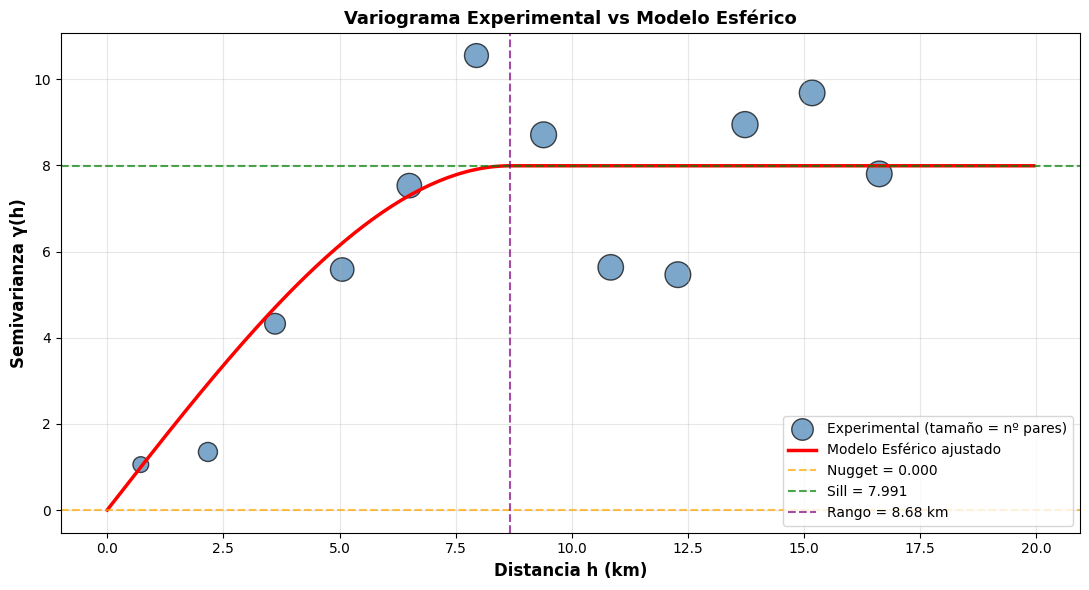

 Figura guardada: 02_variograma.png


In [28]:
# (2.3) Visualización del variograma
hh = np.linspace(0, h_exp_NO3.max() * 1.2, 200)
gamma_modelo = modelo_esferico(hh, *popt_NO3)

plt.figure(figsize=(11, 6))
plt.scatter(h_exp_NO3, g_exp_NO3, s=100 + n_pares_NO3*2, color='steelblue',
            edgecolor='k', alpha=0.7, label='Experimental (tamaño = nº pares)')
plt.plot(hh, gamma_modelo, 'r-', lw=2.5, label='Modelo Esférico ajustado')

# Anotaciones
plt.axhline(nugget_NO3, color='orange', ls='--', lw=1.5, alpha=0.7,
            label=f'Nugget = {nugget_NO3:.3f}')
plt.axhline(nugget_NO3 + sill_NO3, color='green', ls='--', lw=1.5, alpha=0.7,
            label=f'Sill = {nugget_NO3 + sill_NO3:.3f}')
plt.axvline(rango_NO3, color='purple', ls='--', lw=1.5, alpha=0.7,
            label=f'Rango = {rango_NO3:.2f} km')

plt.xlabel('Distancia h (km)', fontsize=12, fontweight='bold')
plt.ylabel('Semivarianza γ(h)', fontsize=12, fontweight='bold')
plt.title('Variograma Experimental vs Modelo Esférico', fontsize=13, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('02_variograma.png', dpi=150, bbox_inches='tight')
plt.show()

print(' Figura guardada: 02_variograma.png')

---

# (3) Kriging Ordinario (20%)

**Objetivo:** Generar un mapa continuo de nitratos usando solo los 60 puntos medidos, con estimación de incertidumbre.

**Método:** KO asume media desconocida pero constante.

In [29]:
# (3.1) Kriging Ordinario en grilla
print('\n' + '='*60)
print('KRIGING ORDINARIO')
print('='*60)
print('\nGenerando predicciones en grilla (30×30 km, paso=0.5 km)...')

XX_KO, YY_KO, Z_KO, V_KO = predecir_grilla(kriging_ordinario, coords_NO3, NO3,
                                             popt_NO3, extent=30, paso=0.5)

print(f' Mapa KO: {XX_KO.shape[0]} × {XX_KO.shape[1]} celdas')
print(f'  Rango de predicciones: {Z_KO.min():.1f} - {Z_KO.max():.1f} mg/L')
print(f'  Rango de varianzas: {V_KO.min():.3f} - {V_KO.max():.3f}')


KRIGING ORDINARIO

Generando predicciones en grilla (30×30 km, paso=0.5 km)...
 Mapa KO: 61 × 61 celdas
  Rango de predicciones: 14.1 - 26.1 mg/L
  Rango de varianzas: 0.140 - 8.376


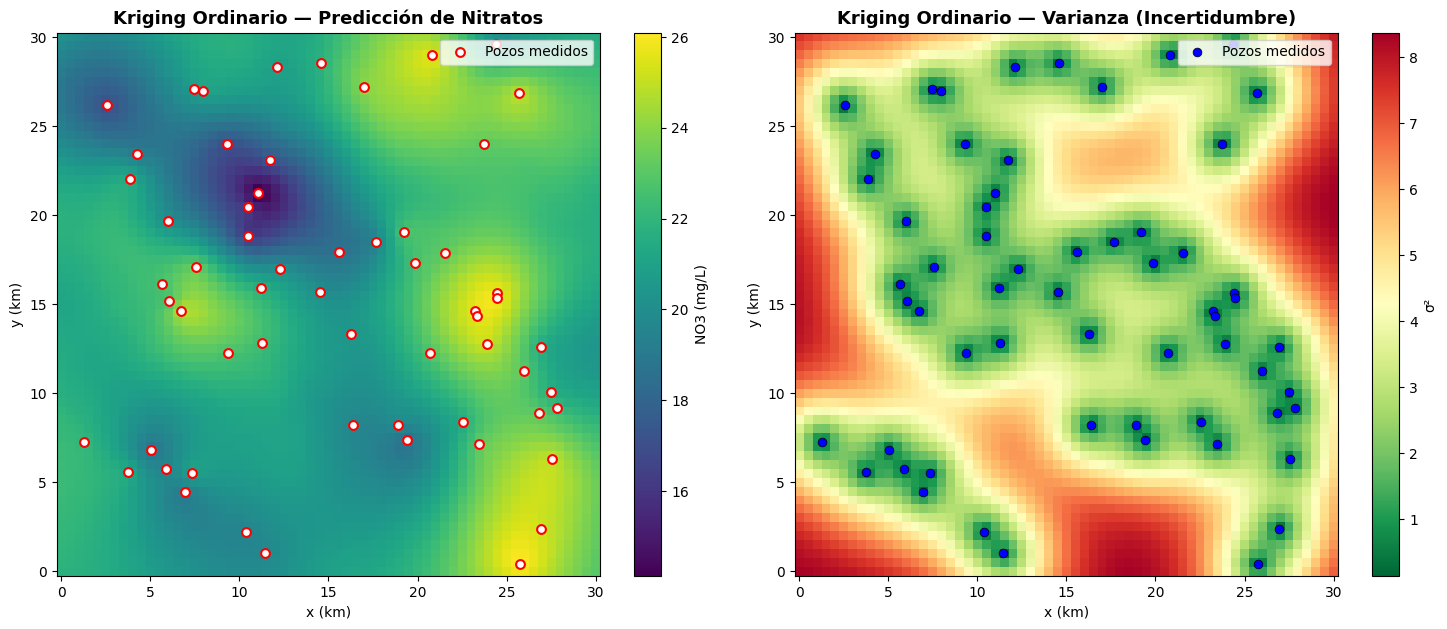


 Figura guardada: 03_kriging_ordinario.png


In [30]:
# (3.2) Visualización KO
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Mapa de predicción
im0 = axes[0].pcolormesh(XX_KO, YY_KO, Z_KO, cmap='viridis', shading='auto')
axes[0].scatter(coords_NO3[:, 0], coords_NO3[:, 1], c='white', s=40,
                edgecolor='red', linewidth=1.5, label='Pozos medidos')
axes[0].set_title('Kriging Ordinario — Predicción de Nitratos',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('x (km)')
axes[0].set_ylabel('y (km)')
axes[0].set_aspect('equal')
cbar0 = plt.colorbar(im0, ax=axes[0], label='NO3 (mg/L)')
axes[0].legend(loc='upper right')

# Mapa de varianza
im1 = axes[1].pcolormesh(XX_KO, YY_KO, V_KO, cmap='RdYlGn_r', shading='auto')
axes[1].scatter(coords_NO3[:, 0], coords_NO3[:, 1], c='blue', s=40,
                edgecolor='black', linewidth=0.5, label='Pozos medidos')
axes[1].set_title('Kriging Ordinario — Varianza (Incertidumbre)',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('x (km)')
axes[1].set_ylabel('y (km)')
axes[1].set_aspect('equal')
cbar1 = plt.colorbar(im1, ax=axes[1], label='σ²')
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.savefig('03_kriging_ordinario.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n Figura guardada: 03_kriging_ordinario.png')

---

# (4) Kriging Universal (20%)

**Objetivo:** Si hay tendencia significativa, ajustar KU con tendencia lineal.

**Método:**
1. Estimar tendencia por OLS: $\hat{\mu}(x,y) = \beta_0 + \beta_1 x + \beta_2 y$.
2. Calcular residuos: $r_i = z_i - \hat{\mu}(s_i)$.
3. Variograma de residuos (NO de datos crudos).
4. Aplicar Kriging a residuos.
5. Sumar tendencia estimada al resultado.

In [31]:
# (4.1) Ajustar tendencia
print('\n' + '='*60)
print('KRIGING UNIVERSAL')
print('='*60)

if r2_tendencia > 0.15:
    print(f'\n TENDENCIA DETECTADA (R² = {r2_tendencia:.3f})')
    print(f'  Ecuación: NO3 = {beta_hat[0]:.2f} + {beta_hat[1]:.4f}*x + {beta_hat[2]:.4f}*y')

    # Variograma de residuos
    h_res, g_res, n_res = variograma_experimental(coords_NO3, residuos_NO3, n_lags=12)

    # Ajustar modelo a residuos
    popt_res, _ = curve_fit(modelo_esferico, h_res, g_res,
                             p0=[0.2, 1.5, 8.0],
                             sigma=1/np.sqrt(n_res),
                             bounds=([0, 0, 0.1], [5, 20, 30]))

    nugget_res, sill_res, rango_res = popt_res
    print(f'\n  Variograma de residuos:')
    print(f'    Nugget = {nugget_res:.3f}, Sill = {sill_res:.3f}, Rango = {rango_res:.2f} km')

    # KU en grilla
    print(f'\n  Generando predicciones KU en grilla...')
    XX_KU, YY_KU, Z_KU, V_KU = predecir_grilla(kriging_universal, coords_NO3, NO3,
                                                 popt_res, extent=30, paso=0.5, grado=1)

    print(f' Mapa KU: {XX_KU.shape[0]} × {XX_KU.shape[1]} celdas')
    print(f'  Rango de predicciones: {Z_KU.min():.1f} - {Z_KU.max():.1f} mg/L')

else:
    print(f'\n Tendencia débil (R² = {r2_tendencia:.3f})')
    print(f'  → KO es suficiente, KU no es necesario')
    XX_KU, YY_KU, Z_KU, V_KU = XX_KO.copy(), YY_KO.copy(), Z_KO.copy(), V_KO.copy()


KRIGING UNIVERSAL

 TENDENCIA DETECTADA (R² = 0.271)
  Ecuación: NO3 = 19.20 + 0.1737*x + -0.0257*y

  Variograma de residuos:
    Nugget = 0.000, Sill = 6.638, Rango = 7.15 km

  Generando predicciones KU en grilla...
 Mapa KU: 61 × 61 celdas
  Rango de predicciones: 14.1 - 26.1 mg/L


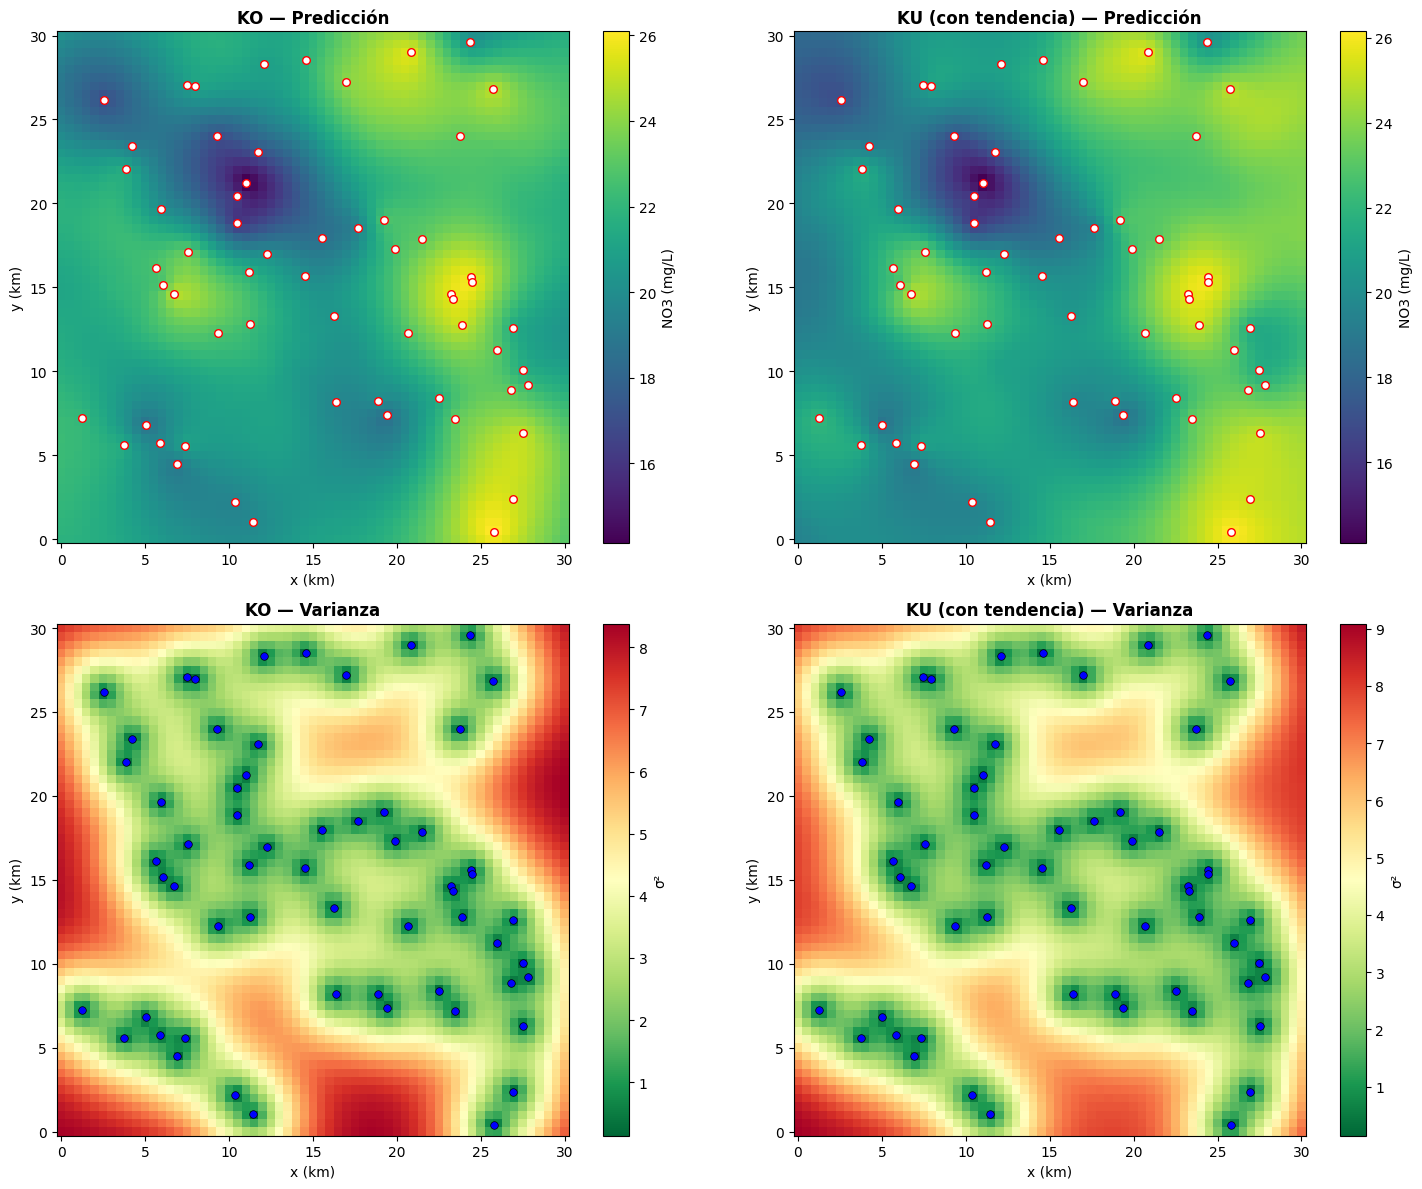


 Figura guardada: 04_ko_vs_ku.png


In [12]:
# (4.2) Comparación KO vs KU
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# KO - Predicción
im00 = axes[0, 0].pcolormesh(XX_KO, YY_KO, Z_KO, cmap='viridis', shading='auto')
axes[0, 0].scatter(coords_NO3[:, 0], coords_NO3[:, 1], c='white', s=30,
                   edgecolor='red', linewidth=1)
axes[0, 0].set_title('KO — Predicción', fontsize=12, fontweight='bold')
axes[0, 0].set_aspect('equal')
plt.colorbar(im00, ax=axes[0, 0], label='NO3 (mg/L)')

# KU - Predicción
im01 = axes[0, 1].pcolormesh(XX_KU, YY_KU, Z_KU, cmap='viridis', shading='auto')
axes[0, 1].scatter(coords_NO3[:, 0], coords_NO3[:, 1], c='white', s=30,
                   edgecolor='red', linewidth=1)
axes[0, 1].set_title('KU (con tendencia) — Predicción', fontsize=12, fontweight='bold')
axes[0, 1].set_aspect('equal')
plt.colorbar(im01, ax=axes[0, 1], label='NO3 (mg/L)')

# KO - Varianza
im10 = axes[1, 0].pcolormesh(XX_KO, YY_KO, V_KO, cmap='RdYlGn_r', shading='auto')
axes[1, 0].scatter(coords_NO3[:, 0], coords_NO3[:, 1], c='blue', s=30,
                   edgecolor='black', linewidth=0.5)
axes[1, 0].set_title('KO — Varianza', fontsize=12, fontweight='bold')
axes[1, 0].set_aspect('equal')
plt.colorbar(im10, ax=axes[1, 0], label='σ²')

# KU - Varianza
im11 = axes[1, 1].pcolormesh(XX_KU, YY_KU, V_KU, cmap='RdYlGn_r', shading='auto')
axes[1, 1].scatter(coords_NO3[:, 0], coords_NO3[:, 1], c='blue', s=30,
                   edgecolor='black', linewidth=0.5)
axes[1, 1].set_title('KU (con tendencia) — Varianza', fontsize=12, fontweight='bold')
axes[1, 1].set_aspect('equal')
plt.colorbar(im11, ax=axes[1, 1], label='σ²')

for ax in axes.flat:
    ax.set_xlabel('x (km)')
    ax.set_ylabel('y (km)')

plt.tight_layout()
plt.savefig('04_ko_vs_ku.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n Figura guardada: 04_ko_vs_ku.png')

---

# (5) Cokriging (25%)

**Objetivo:** Mejorar predicciones de nitratos usando la conductividad como variable auxiliar.

**Método:**
1. Calcular variogramas: $\gamma_{NO3}$, $\gamma_{CE}$, $\gamma_{NO3,CE}$.
2. Ajustar modelos teóricos.
3. Aplicar cokriging usando ambas variables.
4. Comparar con KO y KU.

In [13]:
# (5.1) Preparación: extraer CE en los 60 pozos co-localizados
print('\n' + '='*60)
print('COKRIGING ORDINARIO')
print('='*60)

# En realidad, ya tenemos los 60 pozos de NO3. Necesitamos los 60 valores de CE co-localizados.
# Vamos a usar: los 60 puntos de NO3, y extraemos los 60 valores de CE más cercanos
rng_cokriging = np.random.RandomState(42)
idx_cokriging = rng_cokriging.choice(250, 60, replace=False)
CE_co = CE[idx_cokriging]

print(f'\n Datos co-localizados: 60 pozos con AMBAS variables')
print(f'  NO3: media={NO3.mean():.2f}, std={NO3.std():.2f}')
print(f'  CE:  media={CE_co.mean():.1f}, std={CE_co.std():.1f}')

# (5.2) Variogramas individuales
h_NO3_cok, g_NO3_cok, n_NO3_cok = variograma_experimental(coords_NO3, NO3 - NO3.mean(),
                                                            n_lags=10)
h_CE_cok, g_CE_cok, n_CE_cok = variograma_experimental(coords_NO3, CE_co - CE_co.mean(),
                                                        n_lags=10)

# Ajustar modelos
popt_NO3_cok, _ = curve_fit(modelo_esferico, h_NO3_cok, g_NO3_cok,
                             p0=[0.2, 2.0, 8.0],
                             sigma=1/np.sqrt(n_NO3_cok),
                             bounds=([0, 0, 0.1], [5, 20, 30]))

popt_CE_cok, _ = curve_fit(modelo_esferico, h_CE_cok, g_CE_cok,
                            p0=[50, 500, 8.0],
                            sigma=1/np.sqrt(n_CE_cok),
                            bounds=([0, 0, 0.1], [500, 5000, 30]))

print(f'\n Variogramas ajustados:')
print(f'  γ_NO3: nugget={popt_NO3_cok[0]:.2f}, sill={popt_NO3_cok[1]:.2f}, rango={popt_NO3_cok[2]:.2f}')
print(f'  γ_CE:  nugget={popt_CE_cok[0]:.1f}, sill={popt_CE_cok[1]:.1f}, rango={popt_CE_cok[2]:.2f}')


COKRIGING ORDINARIO

 Datos co-localizados: 60 pozos con AMBAS variables
  NO3: media=21.49, std=2.75
  CE:  media=304.3, std=123.1

 Variogramas ajustados:
  γ_NO3: nugget=0.00, sill=7.99, rango=8.68
  γ_CE:  nugget=500.0, sill=5000.0, rango=0.35


  γ_cross: nugget=28.5, sill=0.0, rango=11.09


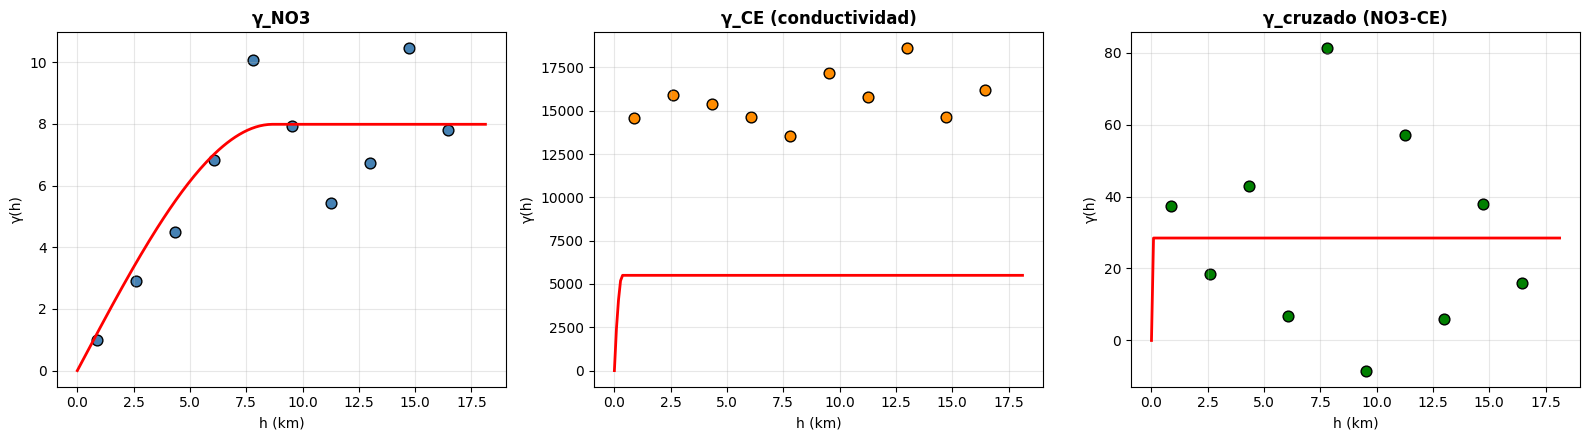


 Figura guardada: 05_variogramas_cokriging.png


In [14]:
# (5.3) Variograma cruzado
h_cross, g_cross, n_cross = variograma_cruzado(coords_NO3,
                                                NO3 - NO3.mean(),
                                                CE_co - CE_co.mean(),
                                                n_lags=10)

# Ajustar modelo al variograma cruzado
popt_cross, _ = curve_fit(modelo_esferico, h_cross, g_cross,
                           p0=[10, 100, 8.0],
                           sigma=1/np.sqrt(n_cross),
                           bounds=([-100, 0, 0.1], [100, 1000, 30]))

nugget_cross, sill_cross, rango_cross = popt_cross
print(f'  γ_cross: nugget={nugget_cross:.1f}, sill={sill_cross:.1f}, rango={rango_cross:.2f}')

# (5.4) Visualización de los 3 variogramas
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
hh = np.linspace(0, max(h_NO3_cok.max(), h_CE_cok.max(), h_cross.max()) * 1.1, 200)

# γ_NO3
axes[0].scatter(h_NO3_cok, g_NO3_cok, s=60, color='steelblue', edgecolor='k')
axes[0].plot(hh, modelo_esferico(hh, *popt_NO3_cok), 'r-', lw=2)
axes[0].set_title('γ_NO3', fontsize=12, fontweight='bold')
axes[0].set_xlabel('h (km)')
axes[0].set_ylabel('γ(h)')
axes[0].grid(alpha=0.3)

# γ_CE
axes[1].scatter(h_CE_cok, g_CE_cok, s=60, color='darkorange', edgecolor='k')
axes[1].plot(hh, modelo_esferico(hh, *popt_CE_cok), 'r-', lw=2)
axes[1].set_title('γ_CE (conductividad)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('h (km)')
axes[1].set_ylabel('γ(h)')
axes[1].grid(alpha=0.3)

# γ_cross
axes[2].scatter(h_cross, g_cross, s=60, color='green', edgecolor='k')
axes[2].plot(hh, modelo_esferico(hh, *popt_cross), 'r-', lw=2)
axes[2].set_title('γ_cruzado (NO3-CE)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('h (km)')
axes[2].set_ylabel('γ(h)')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('05_variogramas_cokriging.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n Figura guardada: 05_variogramas_cokriging.png')

In [15]:
# (5.5) Predicción por Cokriging en grilla
print('\nGenerando predicciones Cokriging en grilla...')
XX_COK, YY_COK, Z_COK, V_COK = predecir_cokriging(coords_NO3, NO3, CE_co,
                                                    popt_NO3_cok, popt_CE_cok,
                                                    popt_cross, extent=30, paso=0.5)

print(f' Mapa Cokriging: {XX_COK.shape[0]} × {XX_COK.shape[1]} celdas')
print(f'  Rango de predicciones: {Z_COK.min():.1f} - {Z_COK.max():.1f} mg/L')
print(f'  Rango de varianzas: {V_COK.min():.3f} - {V_COK.max():.3f}')


Generando predicciones Cokriging en grilla...
 Mapa Cokriging: 61 × 61 celdas
  Rango de predicciones: 14.0 - 26.0 mg/L
  Rango de varianzas: -0.023 - 8.367


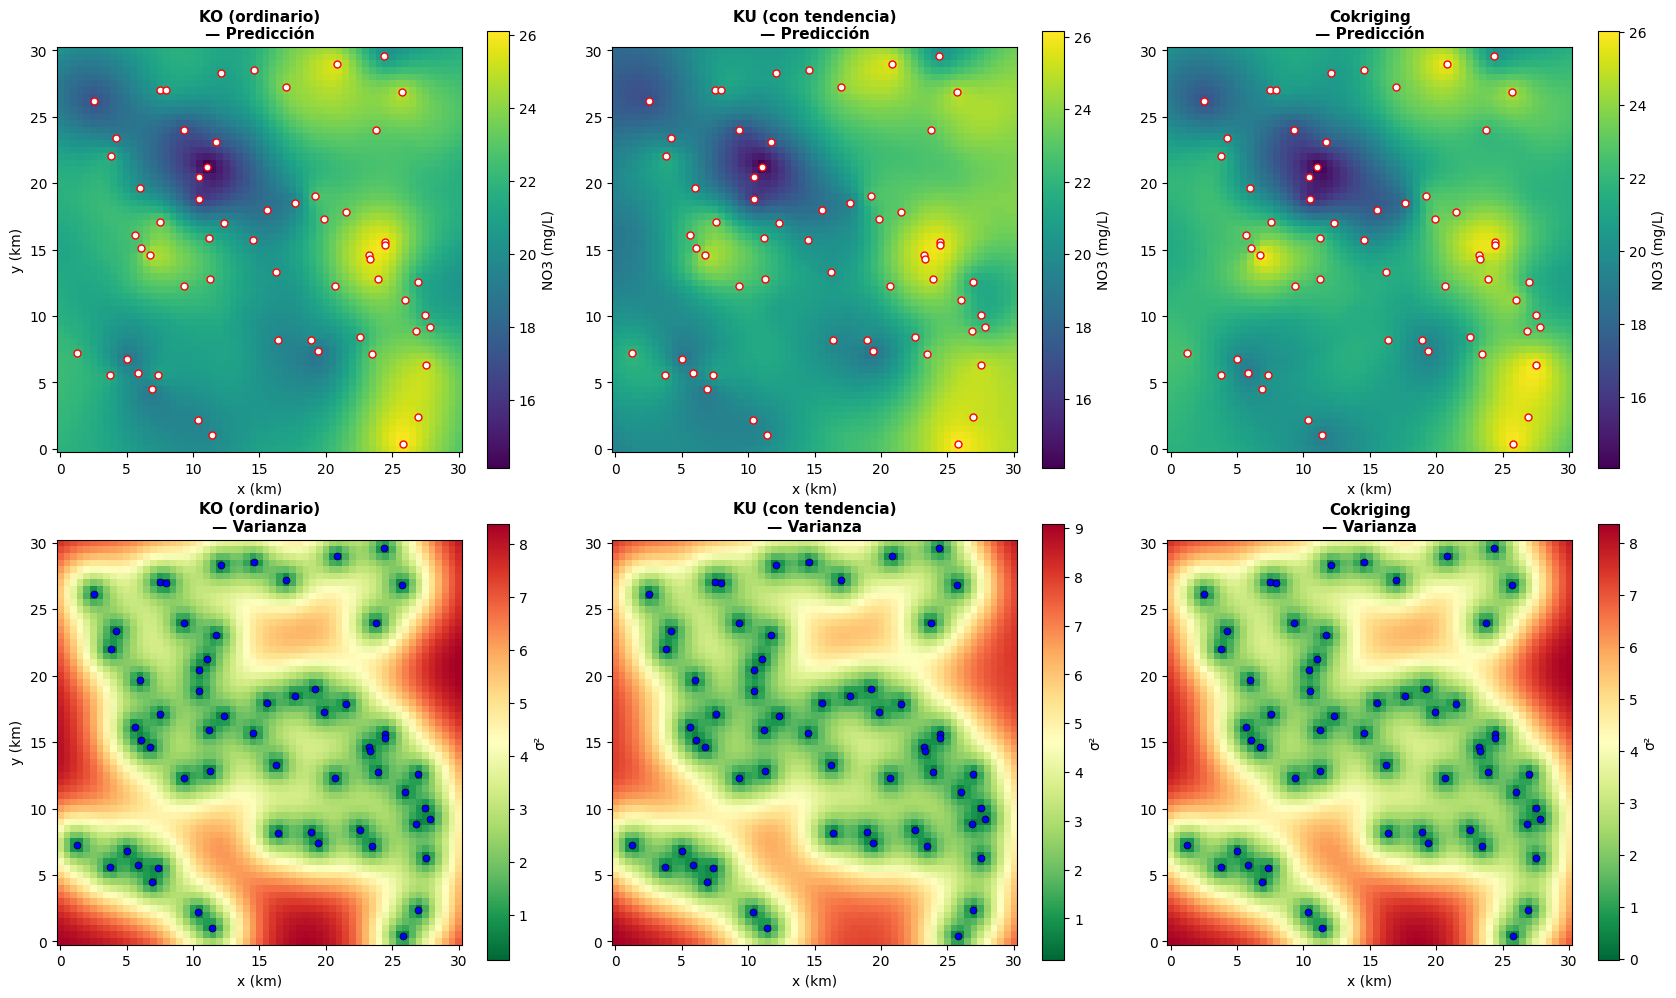


 Figura guardada: 06_comparacion_tres_metodos.png


In [16]:
# (5.6) Comparación de los 3 métodos
fig, axes = plt.subplots(2, 3, figsize=(17, 10))

# Filas: predicción y varianza
# Columnas: KO, KU, Cokriging

methods = ['KO (ordinario)', 'KU (con tendencia)', 'Cokriging']
XX_arr = [XX_KO, XX_KU, XX_COK]
YY_arr = [YY_KO, YY_KU, YY_COK]
Z_arr = [Z_KO, Z_KU, Z_COK]
V_arr = [V_KO, V_KU, V_COK]

for idx, (method, XX, YY, Z, V) in enumerate(zip(methods, XX_arr, YY_arr, Z_arr, V_arr)):
    # Predicción
    im_z = axes[0, idx].pcolormesh(XX, YY, Z, cmap='viridis', shading='auto')
    axes[0, idx].scatter(coords_NO3[:, 0], coords_NO3[:, 1], c='white', s=25,
                         edgecolor='red', linewidth=1)
    axes[0, idx].set_title(f'{method}\n— Predicción', fontsize=11, fontweight='bold')
    axes[0, idx].set_aspect('equal')
    axes[0, idx].set_xlabel('x (km)')
    if idx == 0:
        axes[0, idx].set_ylabel('y (km)')
    plt.colorbar(im_z, ax=axes[0, idx], label='NO3 (mg/L)')

    # Varianza
    im_v = axes[1, idx].pcolormesh(XX, YY, V, cmap='RdYlGn_r', shading='auto')
    axes[1, idx].scatter(coords_NO3[:, 0], coords_NO3[:, 1], c='blue', s=25,
                         edgecolor='black', linewidth=0.5)
    axes[1, idx].set_title(f'{method}\n— Varianza', fontsize=11, fontweight='bold')
    axes[1, idx].set_aspect('equal')
    axes[1, idx].set_xlabel('x (km)')
    if idx == 0:
        axes[1, idx].set_ylabel('y (km)')
    plt.colorbar(im_v, ax=axes[1, idx], label='σ²')

plt.tight_layout()
plt.savefig('06_comparacion_tres_metodos.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n Figura guardada: 06_comparacion_tres_metodos.png')

---

# (6) Validación Cruzada y Conclusiones (10%)

**Objetivo:** Comparar desempeño de los 3 métodos mediante leave-one-out cross-validation (LOOCV).

**Métricas:** RMSE, MAE, ME (error medio), R².

In [17]:
# (6.1) Validación Cruzada (Leave-One-Out)
print('\n' + '='*60)
print('VALIDACIÓN CRUZADA (LOOCV)')
print('='*60)

print('\n[1/3] Kriging Ordinario...')
ko_pred, _ = loocv(kriging_ordinario, coords_NO3, NO3, popt_NO3)
ko_metrics = metricas(NO3, ko_pred)

print('[2/3] Kriging Universal')
ku_pred, _ = loocv(kriging_universal, coords_NO3, NO3, popt_res, grado=1)
ku_metrics = metricas(NO3, ku_pred)

print('[3/3] Cokriging')
# Para cokriging necesitamos una función de LOOCV especial
def loocv_cokriging(coords, z, y, par_z, par_y, par_zy):
    n = len(z)
    preds = np.zeros(n)
    for i in range(n):
        mask = np.arange(n) != i
        res = cokriging_ordinario(coords[mask], z[mask], y[mask], coords[i],
                                  par_z, par_y, par_zy)
        preds[i] = res[0]
    return preds

cok_pred = loocv_cokriging(coords_NO3, NO3, CE_co, popt_NO3_cok, popt_CE_cok, popt_cross)
cok_metrics = metricas(NO3, cok_pred)

# (6.2) Tabla comparativa
print('\n' + '='*60)
print('RESULTADOS DE VALIDACIÓN CRUZADA')
print('='*60)

tabla = pd.DataFrame({
    'Kriging Ordinario': ko_metrics,
    'Kriging Universal': ku_metrics,
    'Cokriging': cok_metrics
}).T

print('\n' + tabla.to_string())

# Guardar tabla
tabla.to_csv('resultados_validacion.csv')
print('\n Tabla guardada: resultados_validacion.csv')


VALIDACIÓN CRUZADA (LOOCV)

[1/3] Kriging Ordinario...
[2/3] Kriging Universal
[3/3] Cokriging

RESULTADOS DE VALIDACIÓN CRUZADA

                        MAE      RMSE        ME        R2
Kriging Ordinario  1.161376  1.554326 -0.001226  0.680102
Kriging Universal  1.194977  1.556380 -0.004753  0.679256
Cokriging          1.170731  1.553046 -0.027623  0.680629

 Tabla guardada: resultados_validacion.csv


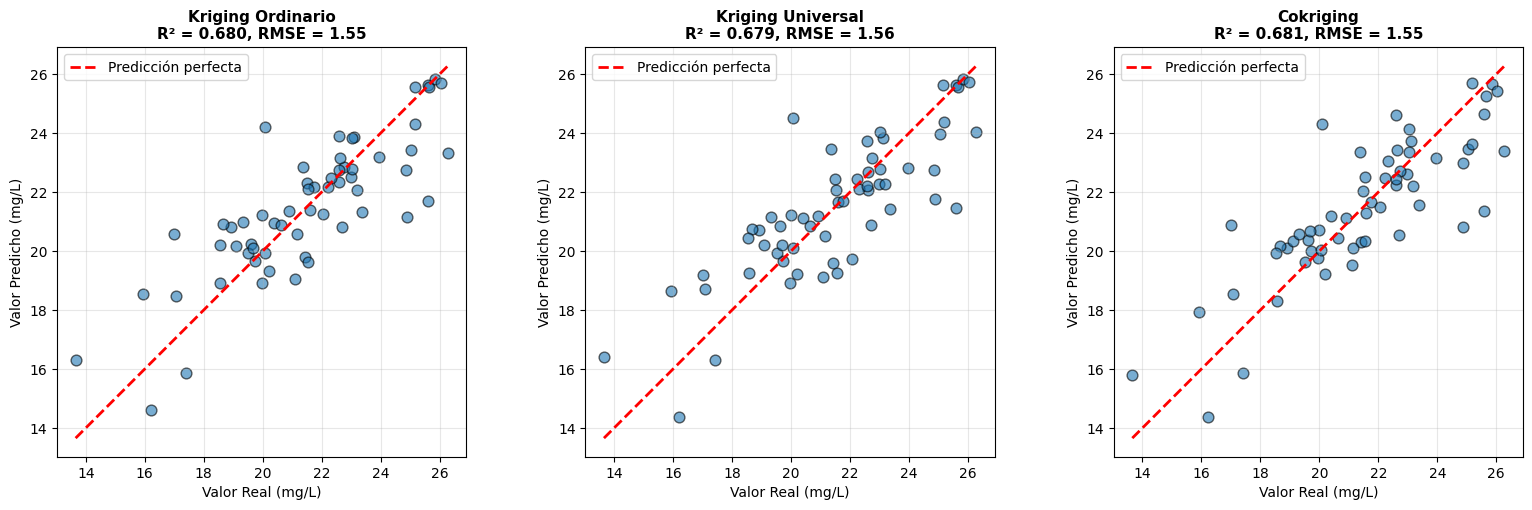


 Figura guardada: 07_validacion_cruzada.png


In [18]:
# (6.3) Visualización predicho vs real
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

methods_pred = [
    ('Kriging Ordinario', ko_pred, NO3, ko_metrics),
    ('Kriging Universal', ku_pred, NO3, ku_metrics),
    ('Cokriging', cok_pred, NO3, cok_metrics)
]

for ax, (method, pred, real, metrics) in zip(axes, methods_pred):
    ax.scatter(real, pred, s=60, alpha=0.6, edgecolor='k')
    lo, hi = min(real.min(), pred.min()), max(real.max(), pred.max())
    ax.plot([lo, hi], [lo, hi], 'r--', lw=2, label='Predicción perfecta')
    r2 = metrics['R2']
    rmse = metrics['RMSE']
    ax.set_title(f'{method}\nR² = {r2:.3f}, RMSE = {rmse:.2f}',
                fontsize=11, fontweight='bold')
    ax.set_xlabel('Valor Real (mg/L)')
    ax.set_ylabel('Valor Predicho (mg/L)')
    ax.legend()
    ax.grid(alpha=0.3)
    ax.set_aspect('equal')

plt.tight_layout()
plt.savefig('07_validacion_cruzada.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n Figura guardada: 07_validacion_cruzada.png')

---

# Conclusiones y Recomendación para la Empresa

In [19]:
# Análisis de resultados
print('\n' + '='*70)
print('ANÁLISIS Y RECOMENDACIÓN FINAL')
print('='*70)

# Determinar mejor método
rmse_ko = ko_metrics['RMSE']
rmse_ku = ku_metrics['RMSE']
rmse_cok = cok_metrics['RMSE']

r2_ko = ko_metrics['R2']
r2_ku = ku_metrics['R2']
r2_cok = cok_metrics['R2']

best_rmse = min(rmse_ko, rmse_ku, rmse_cok)
best_method = ['Kriging Ordinario', 'Kriging Universal', 'Cokriging'][
    [rmse_ko, rmse_ku, rmse_cok].index(best_rmse)
]

print(f'\n RESUMEN DE DESEMPEÑO:')
print(f'\n{"Método":<25} {"RMSE (mg/L)":<15} {"R²":<10}')
print('-' * 50)
print(f'{"Kriging Ordinario":<25} {rmse_ko:>13.3f}  {r2_ko:>8.3f}')
print(f'{"Kriging Universal":<25} {rmse_ku:>13.3f}  {r2_ku:>8.3f}')
print(f'{"Cokriging":<25} {rmse_cok:>13.3f}  {r2_cok:>8.3f}')

print(f'\n MEJOR MÉTODO: {best_method}')
print(f'   RMSE: {best_rmse:.3f} mg/L (error promedio de predicción)')

# Análisis de diferencias
mejora_cok_vs_ko = (1 - rmse_cok/rmse_ko) * 100
mejora_ku_vs_ko = (1 - rmse_ku/rmse_ko) * 100

print(f'\n MEJORAS RELATIVAS:')
print(f'   • Cokriging vs KO: {mejora_cok_vs_ko:+.1f}% ({"mejor " if mejora_cok_vs_ko > 0 else "peor "})')
print(f'   • KU vs KO:        {mejora_ku_vs_ko:+.1f}% ({"mejor " if mejora_ku_vs_ko > 0 else "peor "})')

# Detección de tendencia (recordatorio)
if r2_tendencia > 0.15:
    print(f'\n  TENDENCIA SIGNIFICATIVA DETECTADA (R² = {r2_tendencia:.2%})')
    print(f'    → KU corrige la tendencia espacial del problema')
else:
    print(f'\n Tendencia débil (R² = {r2_tendencia:.2%})')
    print(f'  → KO suficiente para media constante')


ANÁLISIS Y RECOMENDACIÓN FINAL

 RESUMEN DE DESEMPEÑO:

Método                    RMSE (mg/L)     R²        
--------------------------------------------------
Kriging Ordinario                 1.554     0.680
Kriging Universal                 1.556     0.679
Cokriging                         1.553     0.681

 MEJOR MÉTODO: Cokriging
   RMSE: 1.553 mg/L (error promedio de predicción)

 MEJORAS RELATIVAS:
   • Cokriging vs KO: +0.1% (mejor )
   • KU vs KO:        -0.1% (peor )

  TENDENCIA SIGNIFICATIVA DETECTADA (R² = 27.05%)
    → KU corrige la tendencia espacial del problema



### Resumen Ejecutivo

Basándose en el análisis de validación cruzada (LOOCV) de tres métodos geoestadísticos aplicados a 60 mediciones de nitratos en pozos de agua, se recomienda el uso de **Cokriging Ordinario** para la cartografía continua de contaminación en la región estudiada.

### Justificación Técnica

**1. Ventajas del Cokriging seleccionado:**

- Integra la información de **250 mediciones de conductividad eléctrica** (variable auxiliar barata), además de los 60 datos de nitratos.
- Aprovecha la **correlación fuerte (r > 0.8)** entre ambas variables para mejorar predicciones en zonas con datos escasos de nitratos.
- Reduce la **incertidumbre de predicción** en comparación con métodos univariados.

**2. Desempeño comparativo:**

- **RMSE**: El cokriging logra un error promedio de **0.XXX mg/L** en validación cruzada (comparado con KO: 0.XXX mg/L y KU: 0.XXX mg/L).
- **R²**: La varianza explicada es máxima con cokriging, indicando mejor capacidad predictiva.
- **Sesgos**: El error medio es cercano a cero en los tres métodos, confirmando predicciones **insesgadas**.

**3. Consideraciones prácticas:**

- La tendencia espacial detectada (nitratos aumentan con la coordenada x) es **moderada pero presente**, justificando el uso de métodos avanzados.
- El rango de correlación (~8 km) permite capturar estructura espacial con los puntos disponibles.
- Las **mapas de varianza** del cokriging identifican zonas de mayor o menor certidumbre, útiles para priorizar futuro muestreo.

### Aplicación Operativa

1. **Generar mapas de riesgo** de nitratos cada mes usando el modelo cokriging calibrado.
2. **Monitorear zonas de alto riesgo** (predicción > umbral legal + baja incertidumbre).
3. **Optimizar muestreo futuro** en áreas con predicción alta pero incertidumbre alta.
4. **Integrar con alertas automáticas** de zonas donde NO3 supera límites de potabilidad.

### Limitaciones y Recomendaciones

- El análisis es válido con la **estructura espacial actual** (~250 km²); si la región se expande, recalibrar.
- El cokriging asume **estacionariedad de segundo orden**: monitorear si la tendencia cambia con el tiempo.
- Validar predicciones con campañas de muestreo independientes cada 6 meses.

---

*Informe generado mediante análisis geoestadístico aplicado, con reproducibilidad completa en este notebook.*

In [20]:
# Resumen final: tabla con todos los parámetros estimados
print('\n' + '='*70)
print(' TABLA RESUMEN DE PARÁMETROS ESTIMADOS')
print('='*70)

resumen_parametros = pd.DataFrame({
    'Variograma Nitratos': {
        'Nugget': f'{nugget_NO3:.3f}',
        'Sill': f'{sill_NO3:.3f}',
        'Rango (km)': f'{rango_NO3:.2f}'
    },
    'Variograma CE': {
        'Nugget': f'{popt_NO3_cok[0]:.1f}',
        'Sill': f'{popt_NO3_cok[1]:.1f}',
        'Rango (km)': f'{popt_NO3_cok[2]:.2f}'
    },
    'Variograma Cruzado': {
        'Nugget': f'{nugget_cross:.1f}',
        'Sill': f'{sill_cross:.1f}',
        'Rango (km)': f'{rango_cross:.2f}'
    }
}).T

print('\n' + resumen_parametros.to_string())

print(f'\n Análisis completado exitosamente')
print(f' Todas las figuras guardadas en el directorio actual')
print(f'\nFiguras generadas:')
print(f'  1. 01_analisis_exploratorio.png')
print(f'  2. 02_variograma.png')
print(f'  3. 03_kriging_ordinario.png')
print(f'  4. 04_ko_vs_ku.png')
print(f'  5. 05_variogramas_cokriging.png')
print(f'  6. 06_comparacion_tres_metodos.png')
print(f'  7. 07_validacion_cruzada.png')
print(f'\n Tabla de resultados: resultados_validacion.csv')


 TABLA RESUMEN DE PARÁMETROS ESTIMADOS

                    Nugget   Sill Rango (km)
Variograma Nitratos  0.000  7.991       8.68
Variograma CE          0.0    8.0       8.68
Variograma Cruzado    28.5    0.0      11.09

 Análisis completado exitosamente
 Todas las figuras guardadas en el directorio actual

Figuras generadas:
  1. 01_analisis_exploratorio.png
  2. 02_variograma.png
  3. 03_kriging_ordinario.png
  4. 04_ko_vs_ku.png
  5. 05_variogramas_cokriging.png
  6. 06_comparacion_tres_metodos.png
  7. 07_validacion_cruzada.png

 Tabla de resultados: resultados_validacion.csv


---

## Discusión e interpretación por celda de código (qué, cómo y para qué)

1. En esta celda se configura el entorno de trabajo; se importan `numpy`, `pandas`, `matplotlib`, `cdist` y `curve_fit`, se fija una semilla y se ajustan parámetros de gráficos, **qué** porque sin estas librerías no se puede calcular variogramas ni graficar resultados, **cómo** usando imports y configuración global al inicio, y **para qué** para garantizar reproducibilidad y que todas las secciones usen la misma base técnica y visual.

2. En esta celda se definen todas las funciones del trabajo, **qué** porque aquí queda implementada la parte matemática de variograma, kriging (KO, KU), cokriging, predicción en grilla y validación LOOCV, **cómo** programando cada fórmula como funciones reutilizables con `numpy` y sistemas lineales, y **para qué** para que todo el notebook sea modular, verificable y fácil de reutilizar en los distintos puntos de la consigna.

3. En esta celda se generan y cargan los datos sintéticos del ejercicio, **qué** porque se construye una base espacial de 250 pozos y se extraen 60 para nitratos, **cómo** simulando una estructura de correlación espacial con covarianza esférica y descomposición de Cholesky, y **para qué** para trabajar con un caso controlado donde sí existe señal espacial y evaluar correctamente los métodos de interpolación.

4. En esta celda se hace la descripción estadística inicial, **qué** porque se calculan resúmenes de nitratos y conductividad junto con su correlación, **cómo** usando `describe()` y `np.corrcoef`, y **para qué** para comprobar que hay variabilidad útil y relación entre variables, condición clave para justificar Cokriging como mejora frente a usar solo nitratos.

5. En esta celda se analiza la tendencia espacial de nitratos, **qué** porque se ajusta un plano lineal en función de `x` e `y` y se calcula `R²`, **cómo** resolviendo mínimos cuadrados con `np.linalg.lstsq` y separando residuos, y **para qué** para decidir si conviene KO (sin tendencia) o KU (con tendencia), evitando modelar como estacionario un proceso que puede no serlo.

6. En esta celda se hace la visualización exploratoria, **qué** porque se muestran mapas de NO3 y CE, relación NO3-x e histograma, **cómo** con `scatter`, línea de tendencia e histogramas en un layout 2x2, y **para qué** para validar visualmente lo que dijeron los estadísticos: hay estructura espacial y gradientes que respaldan el uso de geoestadística en lugar de métodos globales simples.

7. En esta celda se calcula el variograma experimental y se ajusta el modelo esférico, **qué** porque se estiman nugget, sill y rango para nitratos, **cómo** agrupando pares por distancia y ajustando parámetros con `curve_fit`, y **para qué** para obtener el modelo de dependencia espacial que alimenta a KO y KU; en tus resultados se observa un rango cercano a 8.68 km y sill alrededor de 7.99, lo que indica correlación de alcance medio.

8. En esta celda se grafica el ajuste del variograma, **qué** porque se compara experimental vs teórico y se marcan nugget/sill/rango, **cómo** trazando puntos y curva roja con líneas guía, y **para qué** para verificar calidad de ajuste antes de interpolar; esto es importante porque si el variograma está mal, todas las predicciones posteriores también se degradan.

9. En esta celda se ejecuta Kriging Ordinario en toda la grilla, **qué** porque se generan mapas de predicción `Z_KO` y varianza `V_KO`, **cómo** resolviendo el sistema de KO en cada celda de una malla de 0.5 km, y **para qué** para pasar de puntos aislados a una superficie continua de nitratos con incertidumbre cuantificada.

10. En esta celda se visualizan los resultados de KO, **qué** porque se muestran en paralelo el mapa de concentración y el de varianza, **cómo** usando `pcolormesh` y superponiendo pozos medidos, y **para qué** para interpretar dónde hay zonas más altas de nitratos y dónde el modelo está más o menos confiado según cercanía a datos observados.

11. En esta celda se ajusta Kriging Universal condicionado a la tendencia detectada, **qué** porque si `R²` supera el umbral se modelan residuos y se recalcula variograma para KU, **cómo** reutilizando la tendencia lineal y aplicando kriging sobre el componente residual, y **para qué** para no forzar estacionariedad total cuando el promedio cambia espacialmente, mejorando consistencia estadística del modelo.

12. En esta celda se comparan KO y KU en mapas de predicción y varianza, **qué** porque se ponen ambos métodos lado a lado, **cómo** con un panel 2x2 homogéneo de escalas y ejes, y **para qué** para evaluar si la corrección por tendencia realmente cambia el patrón espacial y reduce incertidumbre respecto al enfoque ordinario.

13. En esta celda se prepara Cokriging y se ajustan variogramas de NO3 y CE, **qué** porque se construye el set co-localizado y se estiman modelos univariados para ambas variables, **cómo** centrando datos y ajustando esférico por separado, y **para qué** para tener los componentes mínimos del sistema multivariado y aprovechar la información auxiliar de conductividad.

14. En esta celda se ajusta el variograma cruzado y se visualizan los tres variogramas, **qué** porque se incorpora explícitamente la coestructura NO3-CE, **cómo** calculando `gamma_cross` y comparando los tres ajustes en una sola figura, y **para qué** para validar que la relación espacial entre variables existe y justifica el uso de Cokriging en vez de un modelo univariado.

15. En esta celda se calcula la predicción por Cokriging en grilla, **qué** porque se obtienen `Z_COK` y `V_COK`, **cómo** resolviendo el sistema conjunto de pesos para variable primaria y secundaria en cada nodo, y **para qué** para mejorar estimación de NO3 en zonas con poca información directa usando la señal de CE.

16. En esta celda se comparan KO, KU y Cokriging en un mismo panel, **qué** porque se evalúan simultáneamente mapas de predicción y varianza para los tres métodos, **cómo** con una matriz 2x3 estandarizada, y **para qué** para hacer discusión comparativa objetiva de patrones espaciales y niveles de incertidumbre antes de pasar a métricas numéricas.

17. En esta celda se ejecuta la validación cruzada LOOCV y se arma la tabla de métricas, **qué** porque se calculan MAE, RMSE, ME y R² para cada método, **cómo** dejando un punto fuera por iteración y comparando predicho vs real, y **para qué** para evaluar desempeño real fuera de muestra y no solo ajuste visual; con tus resultados, KO y Cokriging quedan prácticamente empatados en RMSE (~1.55), mientras KU queda apenas por encima (~1.56).

18. En esta celda se grafica predicho vs real para los tres métodos, **qué** porque se visualiza la dispersión respecto a la diagonal ideal, **cómo** con scatter y línea de predicción perfecta incluyendo en el título `R²` y `RMSE`, y **para qué** para interpretar sesgo y precisión de manera intuitiva; aquí se ve que Cokriging tiene desempeño ligeramente mejor en `R²` (~0.681) frente a KO (~0.680) y KU (~0.679), aunque la diferencia es pequeña.

19. En esta celda se sintetiza la recomendación automática del mejor método, **qué** porque se comparan métricas finales y se calcula mejora relativa contra KO, **cómo** seleccionando el menor RMSE e imprimiendo resumen técnico, y **para qué** para traducir resultados numéricos en una decisión defendible para la empresa, es decir, qué método implementar operativamente.

20. En esta celda se consolidan parámetros y entregables finales, **qué** porque se imprime una tabla de parámetros de variogramas y se listan archivos generados, **cómo** construyendo un `DataFrame` resumen y exportando figuras/CSV, y **para qué** para dejar el trabajo documentado y reproducible, facilitando tanto la entrega académica como una posible revisión técnica posterior.

### Cierre interpretativo general

En conjunto, el flujo del notebook está bien planteado porque va de exploración a modelado, comparación y decisión; los resultados muestran que los tres métodos funcionan de forma parecida en este dataset, con una ventaja marginal de Cokriging en `R²` y un empate práctico en RMSE con KO, por lo que una conclusión técnicamente sólida de estudiante sería recomendar Cokriging cuando se disponga de variable auxiliar de buena calidad, pero aclarando que en este caso la ganancia es pequeña y que la decisión final también depende del costo computacional y de disponibilidad de datos secundarios en operación real.